<a href="https://colab.research.google.com/github/olivierlubunga/ai_models/blob/train-ai/VideoGamesRecommenderProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Environment Setup  & Data Engineering




In [60]:
import os
import random
import json
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("step 1.1: fetching and importing datasets")
# downloading the public dataset directly to our environment workspace
!wget -q https://raw.githubusercontent.com/AzizTurki21/DataSetForVGRProject/main/steam-200k.csv

path = "steam-200k.csv"
df = pd.read_csv(path, header=None, names=['user_id', 'game_title', 'behavior', 'value', 'empty'])
df = df.drop('empty', axis=1)

print("raw interaction logs loaded successfully:")
print(df.head())

print("\nstep 1.2: data filtering and cleaning")
# we only keep records where people actually played the game. 'purchase' actions without playtime are dropped.
df = df[df['behavior'] == 'play'].copy()
df.dropna(inplace=True)

# filtering parameters to remove noisy, accidental plays or single-game users
min_games_per_user = 3
min_users_per_game = 5

user_counts = df.groupby('user_id')['game_title'].count()
game_counts = df.groupby('game_title')['user_id'].count()

df = df[df['user_id'].isin(user_counts[user_counts >= min_games_per_user].index)]
df = df[df['game_title'].isin(game_counts[game_counts >= min_users_per_game].index)]

# playtimes are highly skewed (some users have 1 hour, others have 4000 hours).
# we apply a log1p transform to smooth out these variations so gradients dont explode during training.

df['norm_hours'] = np.log1p(df['value'])

scaler = StandardScaler()

df['norm_hours'] = scaler.fit_transform(df[['norm_hours']])

print(f"cleaned row records count: {len(df)}")
print(f"total unique users identified: {df['user_id'].nunique()}")
print(f"total unique games identified: {df['game_title'].nunique()}")


step 1.1: fetching and importing datasets
raw interaction logs loaded successfully:
     user_id                  game_title  behavior  value
0  151603712  The Elder Scrolls V Skyrim  purchase    1.0
1  151603712  The Elder Scrolls V Skyrim      play  273.0
2  151603712                   Fallout 4  purchase    1.0
3  151603712                   Fallout 4      play   87.0
4  151603712                       Spore  purchase    1.0

step 1.2: data filtering and cleaning
cleaned row records count: 57645
total unique users identified: 3464
total unique games identified: 1584



step 1.3: dictionary index mapping


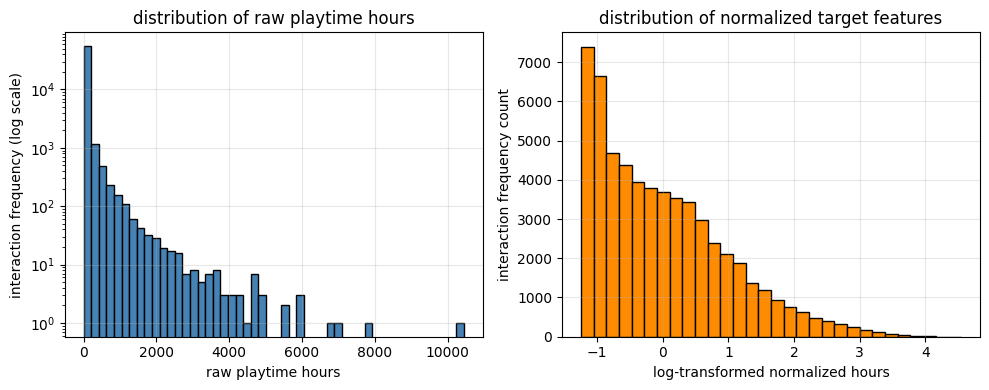

In [61]:
print("\nstep 1.3: dictionary index mapping")
# neural networks need numerical matrix indices rather than text strings or raw database ids
unique_users = df['user_id'].unique()
unique_games = df['game_title'].unique()

user_to_idx = {id: i for i, id in enumerate(unique_users)}
game_to_idx = {title: i for i, title in enumerate(unique_games)}
idx_to_game = {i: title for i, title in enumerate(unique_games)}
idx_to_user = {i: id for i, id in enumerate(unique_users)}

df['user_idx'] = df['user_id'].map(user_to_idx)
df['game_idx'] = df['game_title'].map(game_to_idx)

num_users = len(unique_users)
num_games = len(unique_games)

# plot 1a & 1b: understanding dataset distribution characteristics
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df['value'], bins=50, color='steelblue', edgecolor='black', log=True)
axes[0].set_xlabel('raw playtime hours')
axes[0].set_ylabel('interaction frequency (log scale)')
axes[0].set_title('distribution of raw playtime hours')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['norm_hours'], bins=30, color='darkorange', edgecolor='black')
axes[1].set_xlabel('log-transformed normalized hours')
axes[1].set_ylabel('interaction frequency count')
axes[1].set_title('distribution of normalized target features')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
print("\nstep 1.4: preparing pytorch data pipelines")
class SteamDataset(Dataset):
    def __init__(self, users, games, ratings):
        self.users = torch.tensor(users, dtype=torch.long)
        self.games = torch.tensor(games, dtype=torch.long)
        self.ratings = torch.tensor(ratings, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.games[idx], self.ratings[idx]

# Ensure all user_idx have at least 2 entries for stratification
user_counts_for_stratify = df['user_idx'].value_counts()
users_with_enough_interactions = user_counts_for_stratify[user_counts_for_stratify >= 2].index
df = df[df['user_idx'].isin(users_with_enough_interactions)]

# split the rows into 80% training and 20% testing data
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['user_idx'])

train_dataset = SteamDataset(
    train_df['user_idx'].values,
    train_df['game_idx'].values,
    train_df['norm_hours'].values
)

test_dataset = SteamDataset(
    test_df['user_idx'].values,
    test_df['game_idx'].values,
    test_df['norm_hours'].values
)

print(f"train dataset size: {len(train_dataset)}")
print(f"test dataset size: {len(test_dataset)}")

# pin random generator seeds for batch reproducibility
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(42))
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("data pipelines successfully configured")


step 1.4: preparing pytorch data pipelines
train dataset size: 46111
test dataset size: 11528
data pipelines successfully configured


## 2. Model Architecture

In [63]:
print("\nstep 2.1: defining neural architecture")

class NCF(nn.Module):
    def __init__(self, num_users, num_games, embedding_dim=32):
        super().__init__()

# create matrix lookup beds for learned embedding variables

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.game_embedding = nn.Embedding(num_games, embedding_dim)

# deep neural network layers to learn non-linear matching dynamics
        self.fc_layers = nn.Sequential(
            nn.Linear(embedding_dim * 2, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, user, game):
        user_emb = self.user_embedding(user)
        game_emb = self.game_embedding(game)

# combine vectors horizontally and run through the network layers
        x = torch.cat([user_emb, game_emb], dim=1)
        return self.fc_layers(x).squeeze()

# set all random seeds to guarantee exact alignment across runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NCF(num_users=num_users, num_games=num_games, embedding_dim=32).to(DEVICE)

print(f"model instantiated on target device: {DEVICE}")
print(model)

print("\nstep 2.2: verifying initial embedding state shapes")
print(f"user lookup matrix dimensions: {model.user_embedding.weight.shape}")
print(f"game lookup matrix dimensions: {model.game_embedding.weight.shape}")


step 2.1: defining neural architecture
model instantiated on target device: cpu
NCF(
  (user_embedding): Embedding(3464, 32)
  (game_embedding): Embedding(1584, 32)
  (fc_layers): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=32, out_features=1, bias=True)
  )
)

step 2.2: verifying initial embedding state shapes
user lookup matrix dimensions: torch.Size([3464, 32])
game lookup matrix dimensions: torch.Size([1584, 32])


## 3. Training & Optimization


step 3.1: setting up loss, regularization, and schedulers

step 3.2: starting iterative model training loops
epoch 01/20 | train loss (mse): 0.9552 | val loss (mse): 0.8770 | lr: 0.001
epoch 02/20 | train loss (mse): 0.8574 | val loss (mse): 0.8075 | lr: 0.001
epoch 03/20 | train loss (mse): 0.7855 | val loss (mse): 0.7484 | lr: 0.001
epoch 04/20 | train loss (mse): 0.7293 | val loss (mse): 0.7135 | lr: 0.001
epoch 05/20 | train loss (mse): 0.6945 | val loss (mse): 0.6992 | lr: 0.001
epoch 06/20 | train loss (mse): 0.6747 | val loss (mse): 0.6918 | lr: 0.001
epoch 07/20 | train loss (mse): 0.6588 | val loss (mse): 0.6897 | lr: 0.001
epoch 08/20 | train loss (mse): 0.6455 | val loss (mse): 0.6882 | lr: 0.001
epoch 09/20 | train loss (mse): 0.6317 | val loss (mse): 0.6931 | lr: 0.001
epoch 10/20 | train loss (mse): 0.6201 | val loss (mse): 0.6905 | lr: 0.001
epoch 11/20 | train loss (mse): 0.6085 | val loss (mse): 0.7043 | lr: 0.001

early stopping triggered. validation loss plateaued f

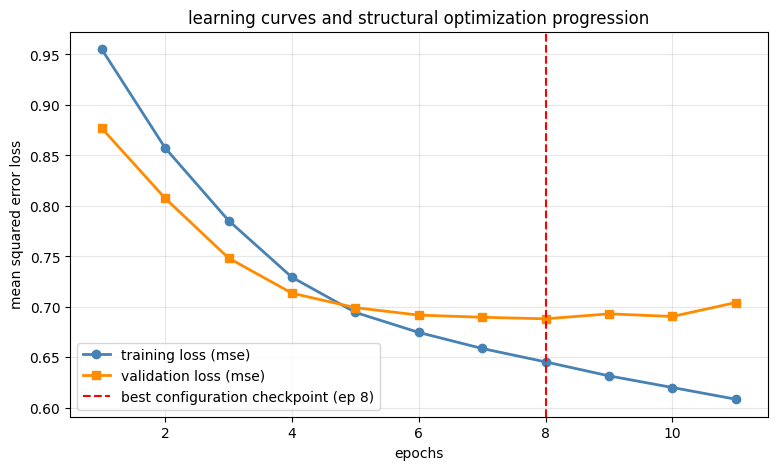

In [64]:
print("\nstep 3.1: setting up loss, regularization, and schedulers")
loss_fn = nn.MSELoss()
# add weight_decay (l2 regularization) to prevent embedding weights from ballooning
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
# dynamically slice the learning rate if validation error improvements halt
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

num_epochs = 20
train_losses = []
val_losses = []

best_val_loss = float('inf')
patience = 3
patience_counter = 0
best_epoch = 0

print("\nstep 3.2: starting iterative model training loops")
for epoch in range(num_epochs):
    # active model training pass
    model.train()
    running_train_loss = 0.0
    for user, game, rating in train_loader:
        user, game, rating = user.to(DEVICE), game.to(DEVICE), rating.to(DEVICE)

        optimizer.zero_grad()
        predictions = model(user, game)
        loss = loss_fn(predictions, rating)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # monitoring validation accuracy to catch overfitting
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for user, game, rating in test_loader:
            user, game, rating = user.to(DEVICE), game.to(DEVICE), rating.to(DEVICE)
            predictions = model(user, game)
            loss = loss_fn(predictions, rating)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    # manual print to replace the old verbose parameter behavior
    current_lr = optimizer.param_groups[0]['lr']
    print(f"epoch {epoch+1:02d}/{num_epochs} | train loss (mse): {avg_train_loss:.4f} | val loss (mse): {avg_val_loss:.4f} | lr: {current_lr}")

    # step our learning rate scheduler based on validation score
    scheduler.step(avg_val_loss)

    # safeguard checkpoints to track the best epoch weights instead of the last one
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_steam_ncf_model.pth")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nearly stopping triggered. validation loss plateaued for {patience} epochs. reverting to best model from epoch {best_epoch}")
            break

# plot 2: structural learning curves
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, label='training loss (mse)', color='steelblue', linewidth=2, marker='o')
plt.plot(range(1, len(val_losses)+1), val_losses, label='validation loss (mse)', color='darkorange', linewidth=2, marker='s')
plt.axvline(best_epoch, color='red', linestyle='--', label=f'best configuration checkpoint (ep {best_epoch})')
plt.xlabel('epochs')
plt.ylabel('mean squared error loss')
plt.title('learning curves and structural optimization progression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Explainability Component


step 4.1: preparing saved model weights

step 4.2: PCA Analysis


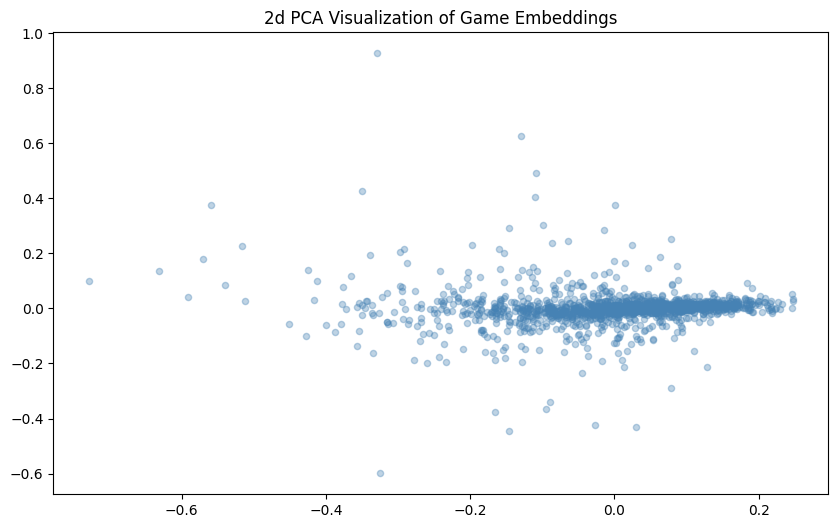


step 4.3: Clustering

step 4.4: Visualization of Clusters


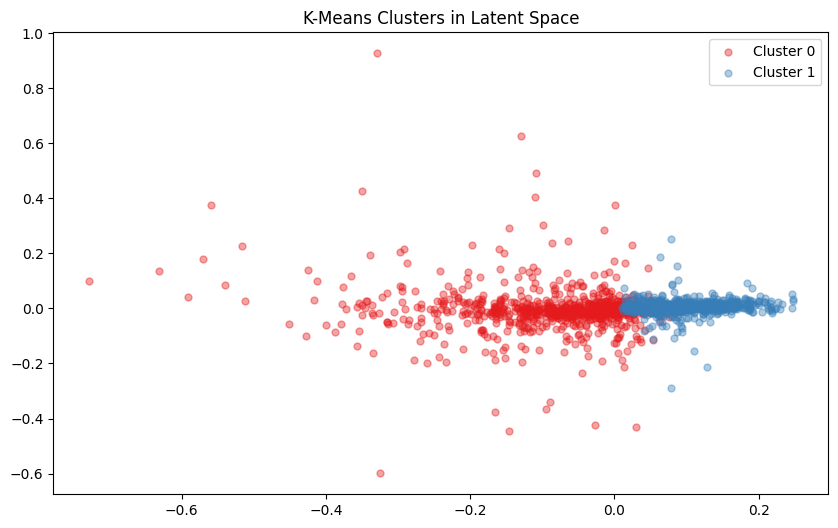

In [70]:
print("\nstep 4.1: preparing saved model weights")
model.load_state_dict(torch.load("best_steam_ncf_model.pth", map_location=DEVICE))
model.eval()

game_embeddings = model.game_embedding.weight.detach().cpu().numpy()
user_embeddings = model.user_embedding.weight.detach().cpu().numpy()

N_CLUSTERS = 2
game_emb_norm = normalize(game_embeddings, norm='l2')

print("\nstep 4.2: PCA Analysis")
pca2d = PCA(n_components=2, random_state=42)
game_2d = pca2d.fit_transform(game_embeddings)

plt.figure(figsize=(10, 6))
plt.scatter(game_2d[:, 0], game_2d[:, 1], alpha=0.35, s=20, color="steelblue", label='catalog items')
plt.title("2d PCA Visualization of Game Embeddings")
plt.show()

print("\nstep 4.3: Clustering")
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init='auto')
labels = kmeans.fit_predict(game_emb_norm)

print("\nstep 4.4: Visualization of Clusters")
colors_palette = ["#e41a1c", "#377eb8", "#4daf4a", "#ff7f00", "#984ea3"]
plt.figure(figsize=(10, 6))
for c in range(N_CLUSTERS):
    mask = labels == c
    if mask.sum() > 0:
        plt.scatter(game_2d[mask, 0], game_2d[mask, 1], s=25, alpha=0.4, color=colors_palette[c], label=f"Cluster {c}")
plt.title("K-Means Clusters in Latent Space")
plt.legend()
plt.show()


step 4.5: Behavioral Analysis Interpretation


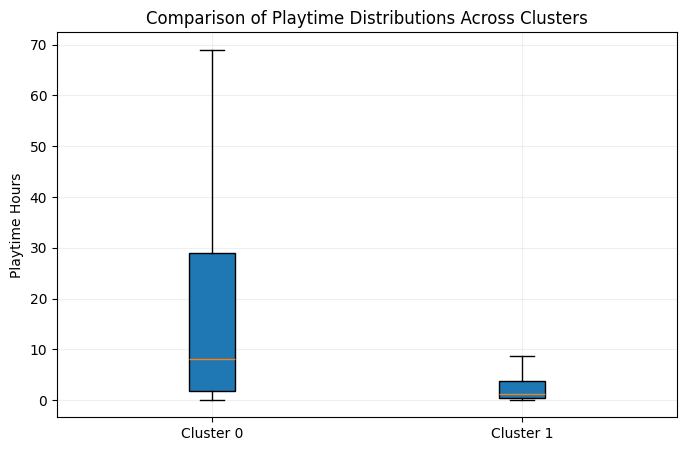


step 4.6: Franchise Continuity Mapping


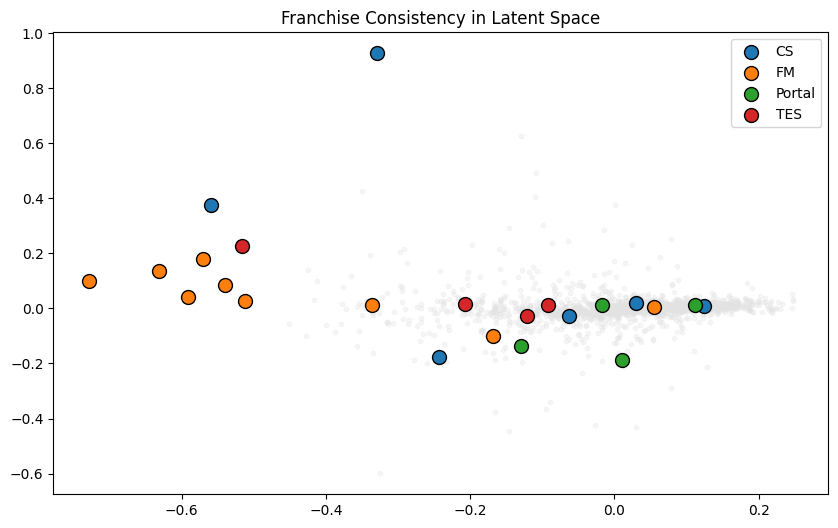

Series: CS              |  83% in Cluster 0
Series: FM              |  89% in Cluster 0
Series: Portal          |  75% in Cluster 0
Series: TES             | 100% in Cluster 0


In [69]:
print("\nstep 4.5: Behavioral Analysis Interpretation")
cluster_hours_list = []
for c in range(N_CLUSTERS):
    mask = labels == c
    game_titles = [idx_to_game[i] for i in np.where(mask)[0]]
    raw_playtimes = df[df['game_title'].isin(game_titles)]['value'].values
    cluster_hours_list.append(raw_playtimes)

plt.figure(figsize=(8, 5))
plt.boxplot(cluster_hours_list, tick_labels=[f'Cluster {c}' for c in range(N_CLUSTERS)], showfliers=False, patch_artist=True)
plt.ylabel('Playtime Hours')
plt.title('Comparison of Playtime Distributions Across Clusters')
plt.grid(True, alpha=0.2)
plt.show()

print("\nstep 4.6: Franchise Continuity Mapping")
target_series = {'Football Manager': 'FM', 'Counter-Strike': 'CS', 'The Elder Scrolls': 'TES', 'Portal': 'Portal'}
series_records = []
for search_term, code in target_series.items():
    for g_idx, title in idx_to_game.items():
        if search_term.lower() in title.lower():
            series_records.append({'franchise': code, 'title': title, 'cluster': labels[g_idx], 'x': game_2d[g_idx, 0], 'y': game_2d[g_idx, 1]})

df_series = pd.DataFrame(series_records)
plt.figure(figsize=(10, 6))
plt.scatter(game_2d[:, 0], game_2d[:, 1], c='#e2e2e2', s=10, alpha=0.3)
for series_name, sub_df in df_series.groupby('franchise'):
    plt.scatter(sub_df['x'], sub_df['y'], s=100, edgecolors='black', label=series_name)

plt.title("Franchise Consistency in Latent Space")
plt.legend()
plt.show()

for series_id, sub_group in df_series.groupby('franchise'):
    dominant = sub_group['cluster'].value_counts(normalize=True).iloc[0] * 100
    print(f"Series: {series_id:<15s} | {dominant:3.0f}% in Cluster {sub_group['cluster'].mode()[0]}")

## 5. Evaluation & Global Inference

In [68]:
print("\nstep 5.1: scoring final validation parameters")
def run_performance_evaluation(data_pipeline_loader):
    model.eval()
    accumulated_loss = 0.0
    with torch.no_grad():
        for user, game, rating in data_pipeline_loader:
            user, game, rating = user.to(DEVICE), game.to(DEVICE), rating.to(DEVICE)
            predicted_scores = model(user, game)
            loss_value = loss_fn(predicted_scores, rating)
            accumulated_loss += loss_value.item()
    return accumulated_loss / len(data_pipeline_loader)

final_evaluation_mse = run_performance_evaluation(test_loader)
print(f"final validation test dataset score (mean squared error): {final_evaluation_mse:.4f}")

# rank the popular games across the dataset to serve as a fallback for cold-start users
popular_baseline_items = df.groupby('game_title')['value'].count().sort_values(ascending=False).index.tolist()

print("\nstep 5.2: building item recommendation generation functions")
def get_recommendations(user_id, top_n=5):
    # checking cold start boundary conditions for unknown users
    if user_id not in user_to_idx:
        print(f"\n[cold-start fallback triggered] user '{user_id}' is completely new. presenting popular community titles:")
        return popular_baseline_items[:top_n]

    # retrieve matching continuous space database references
    u_idx = user_to_idx[user_id]
    already_played_indices = df[df['user_idx'] == u_idx]['game_idx'].unique()
    untouched_catalog_indices = [g_idx for g_idx in range(num_games) if g_idx not in already_played_indices]

    if not untouched_catalog_indices:
        print(f"\n[edge-case warning] active profile '{user_id}' has interacted with all available catalog items! recommending top general items:")
        return popular_baseline_items[:top_n]

    # run predictive calculations through neural layer blocks
    model.eval()
    with torch.no_grad():
        predictions_scores = model(
            torch.tensor([u_idx] * len(untouched_catalog_indices), dtype=torch.long).to(DEVICE),
            torch.tensor(untouched_catalog_indices, dtype=torch.long).to(DEVICE)
        ).cpu().numpy()

    # index sort matching elements to filter top array values
    highest_ranking_pointers = np.argsort(predictions_scores)[::-1][:top_n]
    compiled_recommendations = [idx_to_game[untouched_catalog_indices[idx_ptr]] for idx_ptr in highest_ranking_pointers]

    print(f"\ntop {top_n} personalized recommendations calculated for user: {user_id}")
    for rank_idx, game_title_string in enumerate(compiled_recommendations, 1):
        associated_score = predictions_scores[highest_ranking_pointers[rank_idx-1]]
        print(f"  slot {rank_idx}: {game_title_string:<48s} score affinity={associated_score:.3f}")

    return compiled_recommendations

print("\nstep 5.3: final validation check vectors")
print("running verification test 1: checking an active user present in data logs")
sample_active_user = test_df['user_id'].iloc[0]
get_recommendations(sample_active_user, top_n=5)

print("\n" + "-"*70)
print("running verification test 2: checking a brand new user profile (cold start scenario)")
get_recommendations(user_id=1122334455, top_n=5)


step 5.1: scoring final validation parameters
final validation test dataset score (mean squared error): 0.6882

step 5.2: building item recommendation generation functions

step 5.3: final validation check vectors
running verification test 1: checking an active user present in data logs

top 5 personalized recommendations calculated for user: 8259307
  slot 1: Football Manager 2012                            score affinity=1.158
  slot 2: Football Manager 2013                            score affinity=0.970
  slot 3: Football Manager 2014                            score affinity=0.805
  slot 4: Football Manager 2011                            score affinity=0.755
  slot 5: Football Manager 2015                            score affinity=0.689

----------------------------------------------------------------------
running verification test 2: checking a brand new user profile (cold start scenario)

[cold-start fallback triggered] user '1122334455' is completely new. presenting popular 

['Team Fortress 2',
 'Dota 2',
 'Counter-Strike Global Offensive',
 'Unturned',
 'Left 4 Dead 2']